In [52]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [53]:
import numpy as np
import pandas as pd
from src.features.TimeFeatures import ComputeTimeFeatures
from src.features.CatEntropy import ComputeCatEntropy
from src.features.CatFreq import ComputeCatFreq
from src.preprocessing.PreProcessing import ClientScale,ClientNorm
from src.preprocessing.TrainTestSplit import split

In [54]:
featureset=['Account Number','Age','LogAmount','AmountZScore','MovingAvg','MovingStd','LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']

In [55]:
globalscal=[
    'Age', 'LogAmount', 'LogTimeDiff', 
    'TransactionTypeEntropy', 'ChannelEntropy', 'CardTypeEntropy', 
    'MerchandEntropy', 'CountryEntropy', 'CityEntropy'
]

In [56]:
clientscal=['AmountZScore', 'MovingAvg', 'MovingStd',
    'TransactionTypeFreq', 'ChannelFreq', 'CardTypeFreq', 
    'MerchandFreq', 'CountryFreq', 'CityFreq']

In [57]:
df=pd.read_csv("../data/cdm_transactions.csv")
df.sort_values(['Account Number','Time'],inplace=True)
df['rank']=df.groupby("Account Number")['Time'].rank(method='first',pct=True)

df['Time']=pd.to_datetime(df['Time'])
df['Date']=df['Time'].dt.date
df['Hour']=df['Time'].dt.hour
df['Age']=df['Age'].astype(int)

In [58]:
traindf,testdf=split(df)

traindf=ComputeTimeFeatures(traindf)
traindf=ComputeCatEntropy(traindf)
traindf=ComputeCatFreq(traindf)

traindf=traindf[featureset]

traindf=ClientScale(traindf,'Account Number',clientscal,globalscal)

In [59]:
traindf=traindf.drop(columns='Account Number')

traindf = traindf.replace([np.inf, -np.inf], np.nan).fillna(0)

In [60]:
from src.models.IsolationForest import IsolationForestModel
from src.models.SelfOrganizingMap import SOMModel
from src.models.AutoEncoder import AutoEncoderModel
import matplotlib.pyplot as plt

In [61]:
iso=IsolationForestModel(nestimators=100,maxsamples=256,contamination=0.001)
ae=AutoEncoderModel(inputdim=traindf.shape[1],latentdim=4,lr=0.001,batchsize=64,epochs=50)
som=SOMModel(inputlen=traindf.shape[1],x=20,y=20,sigma=0.8,learning_rate=0.4)

In [62]:
iso.fit(traindf)
ae.fit(traindf)
som.fit(traindf)

Epoch 1/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5232 - val_loss: 0.3810
Epoch 2/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3844 - val_loss: 0.3502
Epoch 3/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3661 - val_loss: 0.3402
Epoch 4/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3576 - val_loss: 0.3354
Epoch 5/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3531 - val_loss: 0.3320
Epoch 6/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3496 - val_loss: 0.3301
Epoch 7/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3461 - val_loss: 0.3261
Epoch 8/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3430 - val_loss: 0.3242
Epoch 9/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3397 - val_loss: 0.3210
Epoch 10/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3369 - val_loss: 0.3180
Epoch 11/50
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3349 - val_loss: 0.3173
Epoch 12/50
1122/1122 ━━━━━━━━

In [63]:
testdf=ComputeTimeFeatures(testdf)
testdf=ComputeCatEntropy(testdf)
testdf=ComputeCatFreq(testdf)

In [64]:
testdf=testdf[featureset]

testdf=ClientScale(testdf,'Account Number',clientscal,globalscal)

testdf=testdf.drop(columns='Account Number')

testdf = testdf.replace([np.inf, -np.inf], np.nan).fillna(0)


In [65]:
results=testdf.copy()
results['isoscores']=iso.score(testdf)
results['aescores']=ae.score(testdf)
results['somscores']=som.score(testdf)

632/632 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


In [66]:
from sklearn.preprocessing import minmax_scale

results['isoscores']=minmax_scale(results['isoscores'])
results['somscores']=minmax_scale(results['somscores'])
results['aescores']=minmax_scale(results['aescores'])

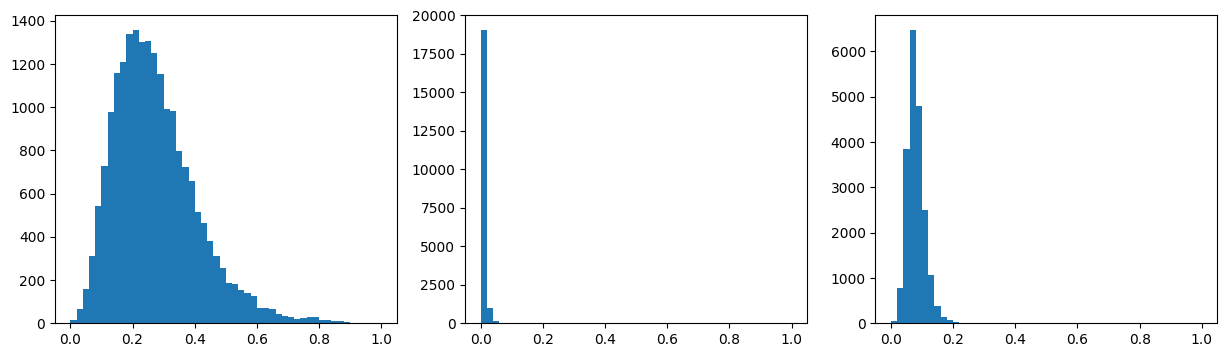

In [67]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,4))

axes[0].hist(results['isoscores'],bins=50)
axes[1].hist(results['aescores'],bins=50)
axes[2].hist(results['somscores'],bins=50)

plt.show()

In [68]:
iso.save(model_name='../models/IF')
ae.save(model_name='../models/AE')
som.save(model_name='../models/SOM')

results.to_csv("../data/results.csv")